# Conversão de dados para pulsos

Os dados gerados pela fonte e codificados tem valores discretos em um determinado conjunto finito $\{x_1, ..., x_M\}$, e precisam ser transformados em um sinal analógico para serem transmitidos. Um primeiro passo nesse sentido é associar cada valor $x_i$  um pulso de duração $T$, que poderá em seguida ser modulado.

Tanto o formato do pulso, quanto a forma de codificar são importantes para contolar o espectro do sinal, conforme descrito a seguir.

Ver: https://wiki.sj.ifsc.edu.br/images/1/1a/Codificacao_LinhaV2.pdf


## Pulsos RZ (Return to Zero)

O **RZ (Return to Zero)** é um formato de codificação em que cada bit é representado por um nível lógico, mas o sinal sempre retorna a zero antes do final do período de bit:
- O **bit 1** é representado por um pulso positivo durante metade do tempo de bit e depois retorna a zero.
- O **bit 0** pode ser representado por ausência de pulso ou por um pulso negativo, dependendo da variação do esquema.

Isso significa que o sinal ocupa mais largura de banda, mas facilita a **sincronização**, pois o retorno a zero fornece uma referência de tempo.


## Pulsos NRZ (Non-Return to Zero)

O **NRZ (Non-Return to Zero)** é um formato em que o sinal **não retorna a zero** no meio do intervalo de bit. Ele pode ser de dois tipos principais:

- **NRZ-L (Level):** cada bit é representado diretamente por um nível de tensão constante (por exemplo, nível alto = 1, nível baixo = 0).
- **NRZ-I (Invert):** a transição de nível ocorre apenas quando há um bit **1**; o bit **0** mantém o nível anterior.

O NRZ é mais eficiente em termos de largura de banda, mas pode sofrer problemas de **sincronização** em longas sequências de 0s ou 1s, já que não há transições suficientes para manter o relógio alinhado.



## Outros tipos de codificação de linha

### **Manchester**

Cada bit é representado por **duas transições** dentro do período de bit.

- O *bit 0* pode ser representado por uma transição alto para baixo.
* O *bit 0* pode ser representado por uma transição baixo para alto.


### **AMI (Alternate Mark Inversion)**

Os bits **0** são enviados como ausência de pulso, enquanto os **1s** alternam entre pulsos positivos e negativos.

Isso ajuda a reduzir a componente DC e facilita a detecção de erros.

### **HDB3 (High Density Bipolar-3)**

É uma evolução do AMI, usada em telecomunicações, que insere violações controladas na sequência para evitar longos períodos sem transições.

Garante sincronização sem aumentar muito a largura de banda.

### **PWM (Pulse Width Modulation)**

A informação é codificada pela **largura do pulso** dentro do intervalo de bit.

Usado em controles digitais e sistemas de potência.

O formato do pulso usado para representar o valor de saída dos codificadores influencia diretamente a largura de banda ocupada. Por exemplo, consideremos um pulso quadrado, dado por
$$\Pi\left(\frac{t}{T}\right) = \left\{\begin{array}{cc}
1     &  -T/2 \leq t \leq T/2\\
0     &  c.c
\end{array}\right.
$$
cujas amplitudes serão alterados pelos valores $x_i$. Aplicando a transformada de Fourier obtemos
$$
\Pi(f) = T.sinc(fT),
$$
que como sabemos tem largura de banda infinita.

Nesse momento, como estamos preocupados somente com a ocupação espectral, podemos utilizar um formato para $p(t)$ que seja mais compacto no tempo. Um exemplo é dado por
$$
cl(t) = \frac{A}{2}\left(1 + \cos\frac{\pi t}{\tau}\right)\Pi\left(\frac{t}{2\tau}\right)
$$
cuja tranformada de Fourier é dada por
$$
CL(f) = \frac{A\tau.sinc(2f\tau)}{1 - (2f\tau)^2}
$$
e está representado na Figura abaixo.

FIGURA

Observe que o cosseno levantado é função limitada do tempo, e aproximadamente limitada da frequência, visto que a potência cai com o qauadrado da frequência.

Nesse momento, como estamos preocupados somente com a ocupação espectral, podemos utilizar um formato para $p(t)$ que seja mais compacto no tempo. Um exemplo é dado por
$$
cl(t) = \frac{A}{2}\left(1 + \cos\frac{\pi t}{\tau}\right)\Pi\left(\frac{t}{2\tau}\right)
$$
cuja tranformada de Fourier é dada por
$$
CL(f) = \frac{A\tau.sinc(2f\tau)}{1 - (2f\tau)^2}
$$
e está representado na Figura abaixo.

FIGURA

Observe que o cosseno levantado é função limitada do tempo, e aproximadamente limitada da frequência, visto que a potência cai com o qauadrado da frequência.

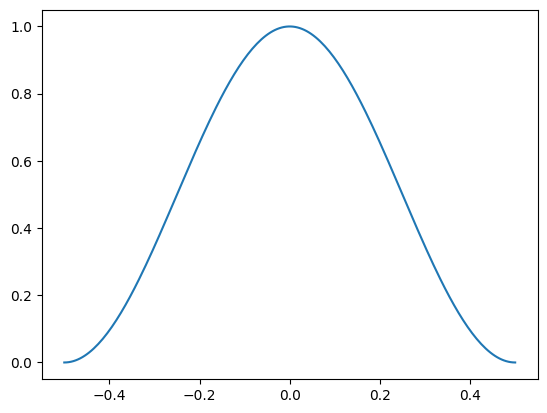

In [6]:
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

A = 1
tau = 0.5
t = np.linspace(-0.5,0.5, 200)
cl = (A/2)*(1+np.cos(np.pi*t/tau))
plt.plot(t, cl)

# Modulação Digital



### M-ASK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = I_kp_T(t)\cos(\omega_c t).
$$

Vamos iniciar considerando que os dados estão representados em binário $\{0,\ 1\}$sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de amplitudes, dai o nome *On-Off Keying - OOK*, 
como representado na figura abaixo (Você pode obter esse gráfico usando o diagrama ASK.grc disponivel na pasta Demonstrações).

![asktconstelacao](./Figuras/OOK.png)

Neste ponto, podemos definir um diagrama para representar a fase e a quadratura que represente as possibilidades do sinal. No caso do ASK o diagrama tem dois pontos, um em zero e outro no eixo real na posição $I_k.$ 

![asktconstelacao](./Figuras/Constelacao_OOK.png)

O espectro do sinal $ASK$ será definido pelo espectro do pulso $p_t(t)$, sendo assim, para um pulso quadrado com frequência de $100 Hz$ cujo espectro é representado na figura abaixo,

![asktconstelacao](./Figuras/Espectro_Pulso.png)

o espectro do sinal OOK consiste no deslocamento pra a frequência da portadora, no exemplo abaixo considere $f_c = 1\ KHz$.

![asktconstelacao](./Figuras/Espectro_OOK.png)

A demodulação de um sinal OOK poder ser feita usando a Detecção Coerente, ou seja, um demodulador de envotória.

Se considerarmos um sinal $M$-ASK, ($M >2$) as análises acima continuam válidas.

### M-FSK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, são aplicados a um modulador em Frequência (FM). que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = \cos[\omega_c t + K_f\int_{-\infty}^{t}I_kp_T(\alpha)d\alpha)].
$$

Sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de frequências, dai o nome *Frequency-Shift Keying - FSK*, 
como representado na figura abaixo.

FIGURA

Um sinal FSK tem duas frequências para um pulso NRZ (*Non Return to Zero*) que tem média zero e amplitudes $m_p$ e $-m_p$ tem as frequências
$$
\omega_{min} = \omega_c - k_f m_p\ e\ \omega_{max} = \omega_c + k_f m_p.
$$
e pode ser escrito como
$s(t) = \left\{\begin{array}{c c} 
\cos(\omega_{min} t) & bit\ 0\\ 
\cos(\omega_{max} t) & bit\ 1
\end{array}\right.$


Neste ponto, como a amplitude é consente, o diagrama de constelação terá apenas um ponto.

FIGURA

Lembremos que na modulação em FM, quando a frequência instantânea é $\omega_i$, naquela posição do espectro está ocupada a largura de banda da mensagem. No caso do sinal $FSK$ com um pulso quadro haverão duas sincs, uma em cada frequência, logo a largura de banda ocupada continua sendo 
$B_{FM} = 2(B_M + k_fm_p).$

FIGURA

É comum usar FSK com um pulso NRZ para evitar o impulso.

### M-PSK

Nessa modulação, os $M$ $I_k \in \{x_1, ..., x_M\}$ símbolos são associados às amplitudes de pulsos $p_T(t)$, com período $T$, são aplicados a um modulador em Fase (PM). que em seguida modulam as amplitudes de uma portadora, gerando o sinal
$$
s(t) = \cos[\omega_c t + K_pI_kp_T(\alpha))].
$$
Logo, a cada valor de $I_k$ associa-se uma fase.E ajustando a codificação dos símbolos, é possível obter um conjunto de fases
$$
\Phi_k \in \{\pm\frac{\pi}{M}, \pm\frac{3\pi}{M}, ..., \pm\frac{(M-1)\pi}{M}\}
$$

Sendo os símbolos binários, $I_k \in \{0, 1\}$ se associarmos os associarmos esse símbolos as amplitudes teremos um chaveamento de Fases, dai o nome *Phase-Shift Keying - FSK*, 
como representado na figura abaixo.

Figura

Um sinal 2-PSK tem duas fases para um pulso NRZ (*Non Return to Zero*) que tem média zero e amplitudes $m_p$ e $-m_p$ tem as frequências
$$
\omega_{min} = \omega_c - k_f m_p\ e\ \omega_{max} = \omega_c + k_f m_p.
$$
e pode ser escrito como
$s(t) = \left\{\begin{array}{c c} 
\cos(\omega_{c} t - \frac{\pi}{2}) & bit\ 0\\ 
\cos(\omega_{c} t + \frac{\pi}{2})& bit\ 1
\end{array}\right.$


Podemos agora desenhar o diagrama de constelação, para $M = 4$ temos

![psktconstelacao](./Figuras/pskconstelacao.png)


A partir deste ponto vamos considerar que  o modulador recebe a sequência de bits a ser transmitida e que pode simultanemante utilizar um cosseno e um seno na mesma frequência, o que vai gerar as modulações em quadratura, conforme descrito a seguir. 

## Modulação $M$-ária em quadratura

Vamos considerar a representação genérica de um sinal modulado como
$$
s(t) = s_i(t - kT) - s_q(t - kT)
$$
sendo
$$
s_i(t) = A_cI_kp_T(t)\cos(\omega_c t) \ \ e \ \ s_q(t) = s(t) = A_c Q_kp_T(t)\sin(\omega_c t)
$$
com $A_c$ a amplitide que é função da potência de transmissão, $I_k\ e\ Q_k \in \{ -M, -M+1, ..., M-1, M\}$ e $p_T(t)$ um pulso com duração de $T$ instantes de tempo.

Para $M = 2$ e $I_k\ e\ Q_k \in \{-1, +1\}$, para representar os possíveis valores temos que usar dois eixos ortigonais, um para a fase outro para quadratura, como mostrado na figura abaixo. Neste caso temos a Modulação em Quadratura de Amplitude (QAM - *Quadrature Amplitude Modulation*).

![mskconstelacao](./Figuras/mskconstelacao.png)

## Modulação PSK $M$-ária

Outra forma de relizar a modução é fazendo
$$
s(t) = s_i(t - kT) - s_q(t - kT)
$$
sendo
$$
s_i(t) = A_c \cos\phi_k\cos(\omega_c t) \ \ e \ \ s_q(t) = A_c \sin\phi_k sin(\omega_c t)
$$

com $A_c$ a amplitide que é função da potência de transmissão, $\phi_k$ um ângulo que é função da informação.

O digrama de constelação de uma modulação PSK consiste de um círculo, com raio $A_c$ e os pontos localizados nos ângulos $\pi/M$. Na figura abaixo tem-se a representação para $M = 4$.

![psktconstelacao](./Figuras/pskconstelacao.png)

## Desempenho das modulações digitais

Para avaliar o desempenho de modulações digitais se analisa a **Probabilidade de erro de Bit** ou a **eficiência espectral**. A primeira medida, considera que o sinal modulado será transmitido pode um canal com ruído que podem causar erros na recepção. A segunda, indica quanto bits por segundo por Hertz podem ser transmitidos.

Considerando inicialmente a Probabilidade de erro de Bit, vamos considerar que ao sinal modulado é adicionado um sinal aleatório com distribuição de probabilidades Gaussiana com média zero e variância $\sigma^2$, ou seja,
$$n(t) \sim \mathcal{N}(0, \sigma^2).$$

Sendo o sinal recebido $$r(t) = s(t) + n(t)$$ com $s(t)$ um sinal produzido por um modulador digital, como $n(t)$ é uma variável aleatória, se desenharmos o diagrama de constelação para $r(t)$ vermos que cada ponto da constelação de $s(t)$ foi acrescrido de um valor guassino, portanto pode ter sido deslocado para qualquer ponto do plano cartesino ao entonro do ponto original.

Como exemplo, considere o sinal $OOK$ ($M = 2$ e $I_k = \{0, 1\}$), cuja constelação está mostrada na figura acima. Ao adicionar o ruído Gaussiano, como representado na fiura abaixo, o ponto da constelação na recepção (considerando a sincronização entre transmissor e receptor) pode estar em qualquer valor no eixo da abscissas (a variação de ponto referente a $I_k = 1$ não está representada) de acorda com a distribuição $\mathcal{N}(0, \sigma^2)$.


![psktconstelacao](./Figuras/OOK_ruido.png)

Caso o receptor use a deteccão baseada em um limiar para definir o bit $b_k$, por exemplo, sendo $I_r$ o valor recebido:
$$
b_k = \left\{\begin{array}{c c} 0_2 & I_r \leq 0,5 \\ 1_2 & I_r > 0,5 \end{array} \right.$$
então dependendo do valor do ruído, um bit $0$ pode ser decidificado como $1$, causando assim um **erro de bit**. 

Se fizermos a razão entre a quantidade de bits demodulados de forma errada pelo total de bits transmitidos, termos a **Probabilidade de Erro de Bit** ($P_b$), que é uma das medidas de desempenho dos sistema de modulação digital.

Para uma mesma modulação, quanto maior for a variância do ruído, $sigma^2$, maior será a $P_b$. Considerando que sinal transmitido tem uma potência $P_s$, e que a potência do ruído Gaussiano é $P_n = \sigma^2$, define-se a **Relação Sinal Ruído** (SNR - *Signal to Noise Ratio*) como $$SNR = P_s/P_n$$ e que norlamente é representada na escala logarítimica $$SNR_dB = 10log_{10}\left(\frac{P_s}{P_n}\right) = 10log_{10}\left(\frac{P_s}{\sigma^2}\right).$$
Os gráficos de desempenho são desenhados usando $SNR_dB \times P_b.$

A probabilidade de erro pode ser calculada considerando o ruído Gaussiano. Por exemplo, para o OOK, se for definido um limitar de decisão $y$, a probabilidade de erro é dela soma da probabilidade de se decidir pelo bit zero quando foi transmitido o bit 1, adicionado a probabildiade de deada por 1 dado que foi transmitido o bit 0, ou seja
$$P_b = P(b_k0|I_k = 1) + P(b_k = 1| I_k = 0)$$
que consiste em 
$$P_b = \int_{y}^{\infty}e^{-\sigma^2/2 x} dx + \int_{-\infty}^{y}e^{-\sigma^2(x-1)}x$$

![psktconstelacao](./Figuras/OOK_ruido_Limiar.png)

<center><font color="red">IGNORAR A PARTIR DESTE PONTO</font></center>


A energia do sinal modulado é dada por
$$
\int_{kT}^{(k+1)} s^2(t)dt = \frac{1}{2}A_c^2(I_k^2)T = \frac{1}{2}A_c^2T
$$
Existem dois tipos básicos de modulação: amplitude e em ângulo. Qualquer sinal modulado pode ser escrito no formato fase e quadratura da seguinte forma
$$
s(t) = A_c[x_i(t)\cos(2\pi f_c t+ \theta) + x_q(t)\sin(2\pi f_c t + \theta)]
$$
sendo $A_c$, $f_c$ e $\theta$ constantes, $x_i(t)$ e $x_q(t)$ componentes que contêm a mensagem. Considerando $x_i(t)$ e $x_q(t)$ estatisticamente independentes e ao menos um deles com média zero tem-se
$$
S(f) = \frac{A_{c}^{2}}{4}[X_i(f - f_c) + X_i(f+f_c) + X_q(f-f_c) + X_q(f+f_c)].
$$
Para uma representação mais compacta, vamos definir uma representação passa baixa como
$$
X_{pb} = X_i(f) + X_q(f)
$$
e então
$$
S(f) = \frac{A^2}{4}\left[X_{pb}(f-f_c)+X_{pb}(f+f_c)\right]
$$

Entretanto, $x_i(t) = \sum_{k} a_k p(t-kD)$ sendo $a_k$ a sequência de dígitos da fonte gerada com taxa $r = 1/D$ e dai tem-se que 
$$
X_i(f) = \sigma_{a}^2 r\mid P(f)\mid^2 + (m_a r)^2\sum_{n=-\infty}^{\infty}\mid P(nr)\mid^2\delta(f-nr)
$$
sendo $m_a$ e $\sigma_a^2$ a média e a variância de $a_k$. A mesma expressão vale para $X_q(f)$.

Considerando $p(t)$ como um pulso retangular tem-se que
$$
\mid P(f)\mid^2 = D^2 sinc^2 fD = \frac{1}{r^2}sinc^2\frac{f}{r}
$$

## Modulações em Amplitude

Considerando inicialmente a modulação em amplitude, se fizermos o bit zero como o ausência de sinal e o bit 1 como o pulso $p(t)$ temos a modulação OOK (*On-Off Keying*), também conhecida como ASK - *Amplitude Shift Keying*, e a componente $x_q(t)$ pode ser feita igual a zero pois não haverá inversão de fase. Assim
$$
x_i(t) = \sum_k a_kp(t-kD),\ \ a_k = 0,1,...,M-1
$$
para um sinal $M$-ário que tem média e variância dados por
$$
m_a = \frac{M-1}{2}\ e\ \sigma_{a}^2 = \frac{M^2-1}{12}
$$
e assim
$$
S(f) = \frac{A_{c}^{2}}{4}\left[\frac{(M^2 -1)}{12r} sinc^2 \frac{(f-f_c)}{r} 
 + \frac{(M-1)^2}{4}\delta(f-f_c) \right. + \left. \frac{(M^2 -1)}{12r} sinc^2 \frac{(f+f_c)}{r} + \frac{(M-1)^2}{4}\delta(f+f_c)\right]
$$

**Exemplo:** Fazendo $M=2$ (binário), $A_c = 4$, $f_c = 5$ temos
na Figura abaixo a representação do sinal OOK no tempo para a sequência $\{1,0,1,0,1,0,1,0,1,0\}$

![asktempo](./Figuras/asktempo.png)

e
$$
S(f) = \left[\frac{1}{r} sinc^2 \frac{(f-5)}{r} + \delta(f-5)
+ \frac{1}{r} sinc^2 \frac{(f+5)}{r} + \delta(f+5)\right]
$$
e na Figura abaixo a parte positiva do espectro do sinal OOK para $r = 1$ e $r = 5$. Observe que o impulso não foi representado nessa figura, mas que a largura de banda do sinal aumenta a medida que $r$ aumenta (ou $D$ diminui), o que é esperado pois nesse caso a taxa de transmissão aumenta.

Além disso, observe que a maior parte da energia está concentrada a uma distância de $r$ Hz da frequência da portadora.

![ookEspectro](./Figuras/ookEspectro.png)


Vamos agora considerar um sinal QAM fazendo
$$
x_i(t) = \sum_k a_{2k}p(t-kD)\ \ e \ \ 
x_q(t) = \sum_k a_{2k+1}p(t-kD)
$$
e com isso poderemos transmitir dois bits de cada vez, um em fase e outro em quadratura, e teremos $D=1/r = 2T_b$. Se fizermos $a_k = \pm 1$ teremos %$m_a = 0$ e $\sigma^{2}_{a} = 1$ e
$$
\mid P(f) \mid^2 = \frac{4}{r_b} sinc^2 \frac{2f}{r_b}
$$
e finalmente
$$
S(f) = \frac{A_{c}^{2}}{4}
$$

## Modulação em fase

Um sinal modulado em fase por uma informação digital será chamado de PSK - *Phase Shift Keying*. Um sinal PSK $M$-ário tem deslocamento de fase $\phi_k$ no intervalo de tempo $kD<t<(k+1)D$ e pode ser expresso por
$$
s(t) = A_c\sum_k \cos(\omega_c t + \theta + \phi_k)p(t-kD)
$$
e as componentes em quadratura e fase podem ser expressas por
$$
x_i(t) = \sum_k I_kp(t-kD)\ \ e\ \ x_q(t) = \sum_k Q_kp(t-kD)
$$
sendo 
$$
I_k = cos\phi_k\ \ e\ \ Q_k = \sin\phi_k
$$
e a relação entre $a_k$ e $\phi_k$ é dada por
$$
\phi_k = \frac{\pi(2a_k + N)}{M},\ \ a_k=0,1,...,M-1
$$
sendo $N$ um valor inteiro, usualmente 0 ou 1.

Pode-se mostrar que 
$$
\overline{I}_k = \overline{Q}_k = 0,\ \ \overline{I^2}_k = \overline{Q^2}_k = 1/2\ e\ \ \overline{I_kQ_j} = 0
$$

Como as componentes em fase e quadratura são estatisticamente independentes tem-se
$$
S_{pb}(f) = 2\frac{r}{2}\mid P(f)\mid^2 = \frac{1}{r} sinc^2\frac{f}{r}
$$
e
$$
S(f) = \frac{A^2}{4}\left[\frac{1}{r} sinc^2\frac{(f-f_c)}{r}+\frac{1}{r} sinc^2\frac{(f+f_c)}{r}\right].
$$

Observe na expressão acima que não existe o impulso, logo PSK é mais eficiente do que ASK.

**Exemplo:** Vamos repetir o exemplo anterior para PSK fazendo $M=2$ (binário), $A_c = 4$, $f_c = 5$ e $N=1$, daí temos
$$
S(f) = \frac{1}{r}\left[ sinc^2 \frac{(f-5)}{r} 
+  sinc^2 \frac{(f+5)}{r} \right]
$$
e na Figura abaixo a parte positiva do espectro do sinal PSK para $r = 1$ e $r = 5$. Observe que o espectro obtido é similar ao da ASK porém sem o impulso, o que indica que PSK é mais eficiente do que ASK.

Além disso, observe que a maior parte da energia está concentrada a uma distância de $r$ Hz da frequência da portadora.

![bpsk](./Figuras/bpsk.png)

## Modulação em Frequência

Aqui teremos a modulacão conhecida como FSK - *Frequency Shift Keying* que terá frequência
$$
f_k = f_c + f_d a_k, \ \ a_k = \pm 1, \pm 3, ...., \pm(M-1)
$$
onde assume-se que $M$ é par. Assim,
$$
s(t) = A_c\sum_k\cos(\omega_c t + \theta + \omega_d a_k t)p(t-kD)
$$

Vamos fazer $M=2$, $D=T_b=1/r_b$, $N=1$ e $f_d = r_b/2$. Sendo $p(t) = u(t) = u(t-kT_b)$ te-se
$$
f_d = r_2/2.
$$
Fazendo $a_k = \pm 1$ teremos
$$
\cos\omega_d a_k t = \cos\omega_d t \ \ \ \sin\omega_d a_k t = a_k\sin\omega_d t
$$
a componente em fase se reduz a 
$$
x_i(t) = \cos\pi r_b t
$$
a componente em quadratura será dada por
$$
x_q(t) = \sum a_k\sin(\pi r_b t)p(t-kD) = \sum a_k\sin(\pi r_b t)[u(t-kT_b) - u(t-kT_b-T_b)]
$$
fazendo
$$
Q_k = (-1)^k a_k
$$
e
$$
p_1(t) = \sin(\pi r_b t)[u(t) - u(t - T_b)]
$$
tem-se 
$$
x_q(t) = \sum_k Q_kp(t-kTb).
$$
 A componente em fase só contribui com impulsos em $r_b/2$ e daí
$$
S(f) = \frac{A_c^2}{4}\left[\frac{1}{4}\left[\delta(f-f_c -\frac{r_b}{2})+\delta(f-f_c +\frac{r_b}{2})\right] - r_b\mid P(f-f_c)\mid^2 \right. 
+ \left.\frac{1}{4}\left[\delta(f+f_c -\frac{r_b}{2})+\delta(f+f_c +\frac{r_b}{2})\right] - r_b\mid P(f+f_c)\mid^2\right]
$$
e
$$
\mid P(f)\mid^2 =\frac{1}{4*r_{b}^2}\left[sinc\frac{f-r_b/2}{r_b} + sinc\frac{f + r_b/2}{r_b}\right]^2%\frac{4}{\pi^2 r_b^2}\left[\frac{\cos(\pi f/r_b)}{(2f/r_b)^2 -1)}\right]^2
$$

**Exemplo:** Reteprindo os exemplo anteriores, fazendo $M=2$ (binário), $A_c = 4$, $f_c = 5$ e $N=1$, temos
$$
S(f) = \frac{1}{r}\left[ sinc^2 \frac{(f-5)}{r} 
+  sinc^2 \frac{(f+5)}{r} \right]
\end{eqnarray}
na Figura abaixo a parte positiva do espectro do sinal PSK para $r = 1$ e $r = 5$. 

![fskespectro](./Figuras/fskespectro.png)


Na Figura abaixo está o espectro do PSK e do FSK. Observe que FSK apesar de ter dois impulsos tem bandas laterais mais baixas.

![pskfskespectro](./Figuras/pskfskespectro.png)